# Customer Churn Analysis
### Exploratory Data Analysis (EDA) Project


### Project Objectives:
- Find why customers are leaving (churn drivers).
- Check which factors matter most (contract, tenure, charges).
- Calculate total monthly money lost due to churn.
- Group customers by risk level (Low, Medium, High).
- Give simple recommendations to stop churn and save revenue.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np 
import pandas as pd
import os

# Determine data path regardless of execution directory
raw_data_path = '../data/raw/Cus_chrn_table.csv' if os.path.exists('../data/raw/Cus_chrn_table.csv') else 'data/raw/Cus_chrn_table.csv'
df = pd.read_csv(raw_data_path, sep=';', quotechar='"')
print(f"Loaded dataset with shape: {df.shape}")


Loaded dataset with shape: (100000, 11)


### DATA INSPECTION

In [2]:
print(df.columns.tolist())
# all columns list

['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges', 'Contract', 'PaymentMethod', 'TotalCharges', 'Churn', 'age_bracket', 'tenure_bracket']


In [3]:
print(df.dtypes)
print(df.head())

CustomerID          int64
Age                 int64
Gender             object
Tenure              int64
MonthlyCharges    float64
Contract           object
PaymentMethod      object
TotalCharges      float64
Churn              object
age_bracket        object
tenure_bracket     object
dtype: object
   CustomerID  Age  Gender  Tenure  MonthlyCharges        Contract  \
0           1   56  Female      68          147.58        Two year   
1           2   69    Male      32           22.54  Month-to-month   
2           3   46  Female      10           52.47        One year   
3           4   32    Male      22          109.67  Month-to-month   
4           5   60  Female      54          130.98  Month-to-month   

      PaymentMethod  TotalCharges Churn age_bracket tenure_bracket  
0     Bank transfer      10052.03    No  Middle_age        Diamond  
1      Mailed check        686.78    No      Senior           Gold  
2  Electronic check        537.88    No  Middle_age         Silver  
3  

In [4]:
print("NUll values", df.isnull().sum())

NUll values CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
age_bracket       0
tenure_bracket    0
dtype: int64


In [5]:
# Duplicates 
print("\n Duplicates :", df.duplicated().sum())


 Duplicates : 0


UNIQUE 

In [6]:
for col in ['Gender', 'Contract', 'PaymentMethod', 'Churn', 'age_bracket', 'tenure_bracket']:
    print(df[col].unique())

['Female' 'Male' 'Other']
['Two year' 'Month-to-month' 'One year']
['Bank transfer' 'Mailed check' 'Electronic check' 'Credit card']
['No' 'Yes']
['Middle_age' 'Senior' 'Adult']
['Diamond' 'Gold' 'Silver' 'New']


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df
print(df['TotalCharges'].isnull().sum())
df['TotalCharges'] = df['TotalCharges'].fillna(0)

0


In [8]:
# astype(str)
for col in ['Gender', 'Contract', 'PaymentMethod', 'Churn']:
    df[col] = df[col].astype(str).str.strip()


In [9]:
df['Churn_Flag'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn_Flag'].sample(5)

88416    1
61418    0
40541    1
68585    0
58716    0
Name: Churn_Flag, dtype: int64

In [10]:
# outlier, sanity check
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges,Churn_Flag
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,49.027240,36.527090,79.974933,2926.264335,0.331440
std,28867.657797,18.177862,20.789552,40.491961,2388.011633,0.470733
min,1.000000,18.000000,1.000000,10.000000,-81.830000,0.000000
25%,25000.750000,33.000000,18.000000,44.720000,963.667500,0.000000
50%,50000.500000,49.000000,37.000000,80.000000,2268.060000,0.000000
75%,75000.250000,65.000000,54.000000,115.050000,4394.327500,1.000000
max,100000.000000,80.000000,72.000000,150.000000,10831.460000,1.000000


In [11]:
print((df['Age'] < 0).sum(),
       (df['Tenure'] < 0).sum(),
         (df['MonthlyCharges'] < 0).sum())

0 0 0


FEATURE CROSS CHECK

In [12]:
df.groupby('age_bracket')['Age'].agg(['min','max','count'])

,min,max,count
age_bracket,,,
Adult,18,39,34882
Middle_age,40,68,45912
Senior,69,80,19206


In [13]:
print(df.groupby('tenure_bracket')['Tenure'].agg(['min','max','count']))

                min  max  count
tenure_bracket                 
Diamond          51   72  30502
Gold             26   50  34753
New               1    6   8370
Silver            7   25  26375


In [14]:
# Save cleaned data to processed folder
clean_export_path = '../data/processed/cleaned_churn_data.csv' if os.path.exists('../data/processed') else 'data/processed/cleaned_churn_data.csv'
df.to_csv(clean_export_path, index=False)
print(f"Cleaned dataset saved successfully to {clean_export_path}. Shape: {df.shape}")


Cleaned dataset saved successfully to ../data/processed/cleaned_churn_data.csv. Shape: (100000, 12)


### EDA
- Visulaization(seaborn) 
- Business questions answered

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

plt.rcParams['figure.figsize'] = (8, 5)
clean_load_path = '../data/processed/cleaned_churn_data.csv' if os.path.exists('../data/processed/cleaned_churn_data.csv') else 'data/processed/cleaned_churn_data.csv'
df = pd.read_csv(clean_load_path)
print(f"Loaded cleaned dataset for EDA: {df.shape}")


Loaded cleaned dataset for EDA: (100000, 12)


Ques- 1 OVERALL CHURN  RATE
33.14%

Overall Churn Rate: 33.14%


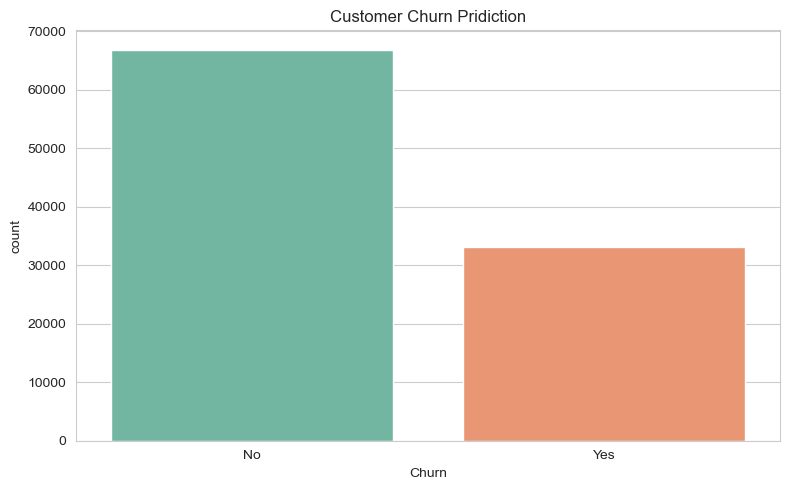

In [16]:
churnrate = df['Churn_Flag'].mean()*100
print(f"Overall Churn Rate: {churnrate:.2f}%")
sns.countplot(data=df,x='Churn',palette='Set2')
plt.title("Customer Churn Pridiction")
plt.tight_layout()
plt.show()

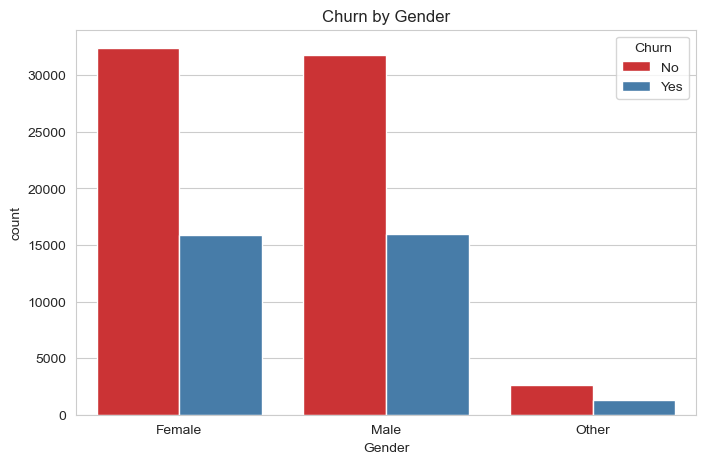

In [17]:
# Gender wise churn  
sns.countplot(data=df, x='Gender',hue='Churn', palette='Set1')
plt.title("Churn by Gender")
plt.show()

### Insight - Gender
- Churn rate is almost identical across Male, Female, and Other (~33%).
- Gender is not a contributing factor to customer churn.


3- Tenure and Churn relation 

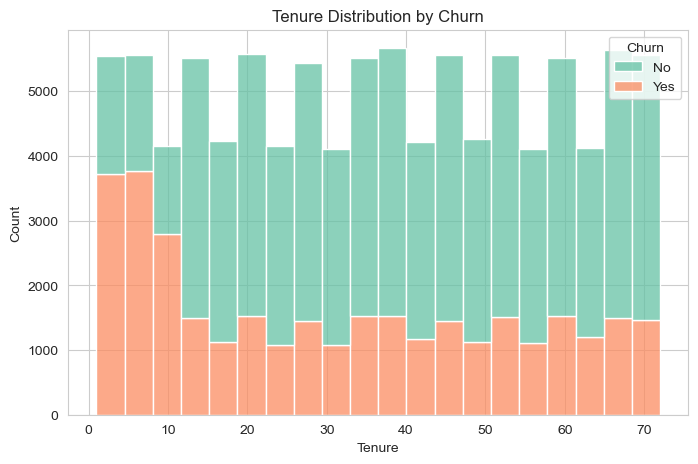

In [18]:
# legend = False
sns.histplot(data=df,x='Tenure',hue='Churn',multiple='stack',bins=20,palette='Set2')
plt.title('Tenure Distribution by Churn')
plt.show()

Text(0.5, 1.0, 'Tenure Spread : Churned vs Retained')

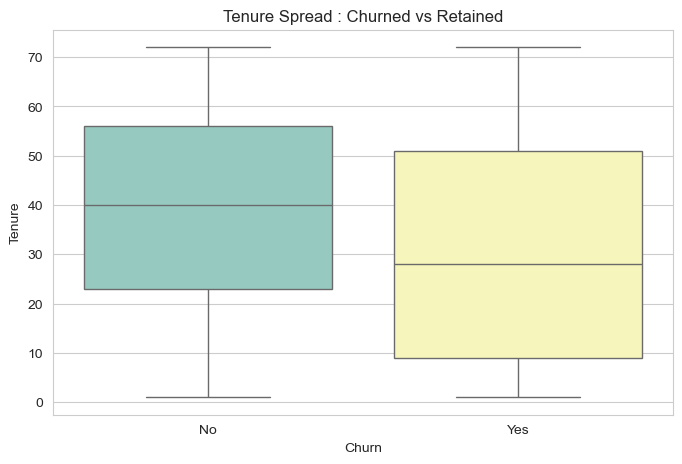

In [19]:
sns.boxplot(data=df,x='Churn',y='Tenure',palette='Set3')
plt.title("Tenure Spread : Churned vs Retained")

### Insight - Tenure
- Churn is heavily concentrated in the first 12 months (early tenure).
- Customers who stay past 12-24 months become significantly more loyal.


4- Contract type churn

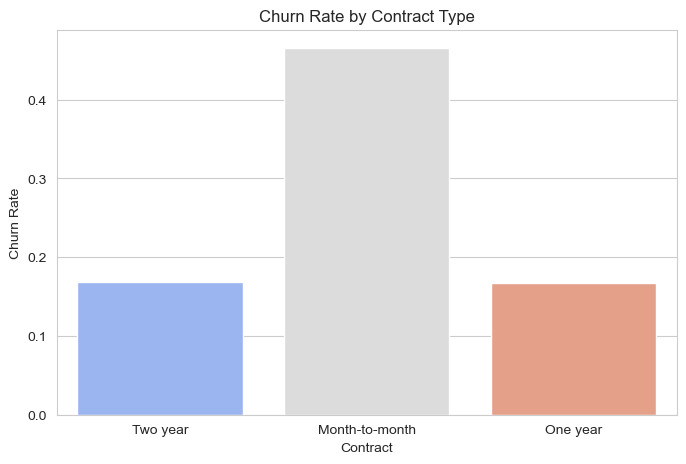

Contract
Month-to-month    46.557407
Two year          16.878531
One year          16.749139
Name: Churn_Flag, dtype: float64


In [20]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Contract', y='Churn_Flag', palette='coolwarm',ci=None)
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Contract Type")
plt.show()

print(df.groupby('Contract')['Churn_Flag'].mean().sort_values(ascending=False) * 100)

### Insight - Contract Type
- Month-to-month contracts show the highest churn rate (46.56%).
- One-year (16.75%) and Two-year (16.88%) contracts show nearly 3x lower churn.
- Contract type is the primary driver of customer churn.


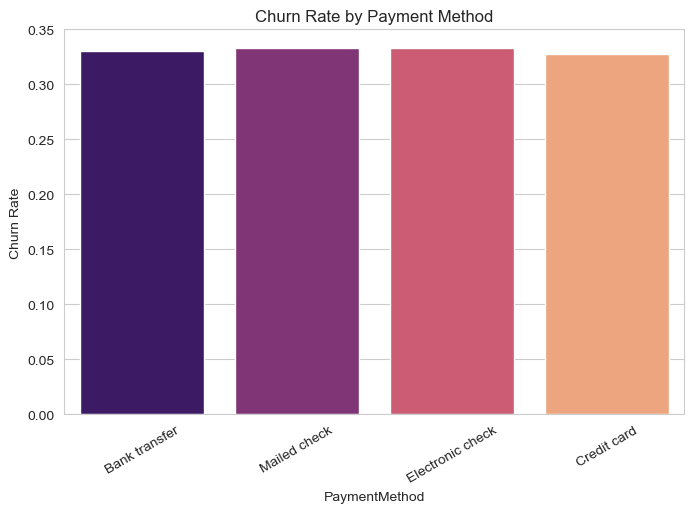

In [21]:
# Payment method affect churn 
sns.barplot(data=df, x='PaymentMethod', y='Churn_Flag', palette='magma', ci=None)
plt.xticks(rotation=30)
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Payment Method")
plt.show()

### Insight - Payment Method
- Analysis shows that all payment methods have a uniform churn rate of ~33%.
- Hence, payment method is not a primary driver of churn and retention budget should not be focused here.


ques - MONTHLY CHARGES HIGH AFFECT CHURN

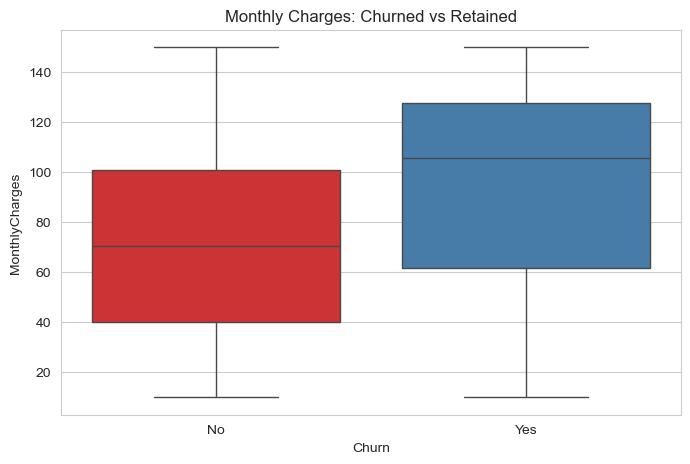

In [22]:
sns.boxplot(data=df,x='Churn', y='MonthlyCharges', palette='Set1')
plt.title("Monthly Charges: Churned vs Retained")
plt.show()

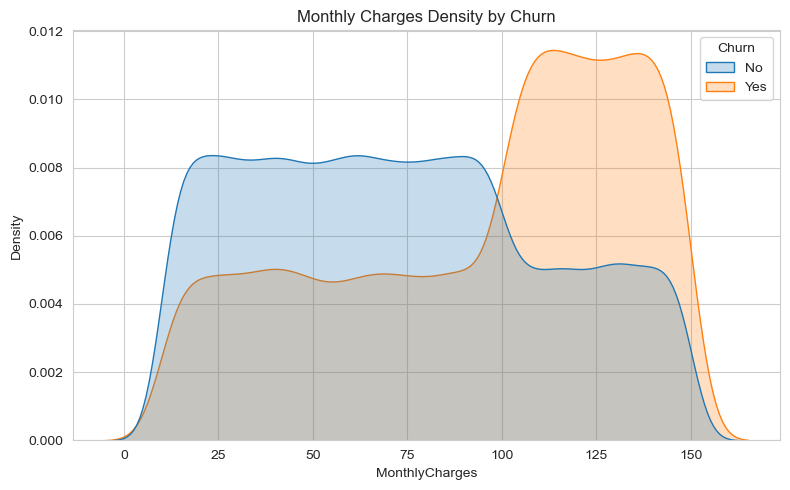

In [23]:
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False)
plt.title("Monthly Charges Density by Churn")
plt.tight_layout()
plt.show() 


### Insight - Monthly Charges
- Churned customers have slightly higher median monthly charges compared to retained customers.
- Higher billing amounts create friction, particularly for customers on month-to-month plans.


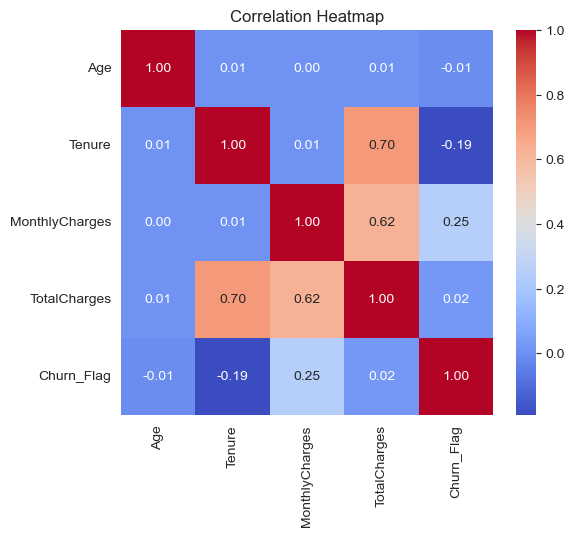

In [24]:
plt.figure(figsize=(6,5))
corr = df[['Age','Tenure','MonthlyCharges','TotalCharges','Churn_Flag']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

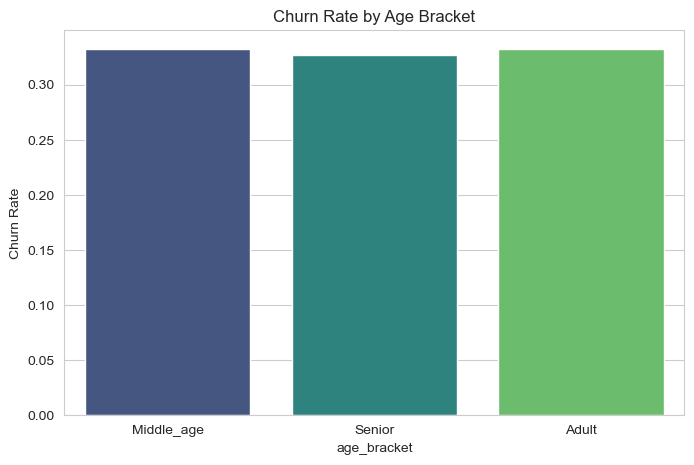

In [25]:
sns.barplot(data=df, x='age_bracket', y='Churn_Flag', palette='viridis', ci=None)
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Age Bracket")
plt.show()


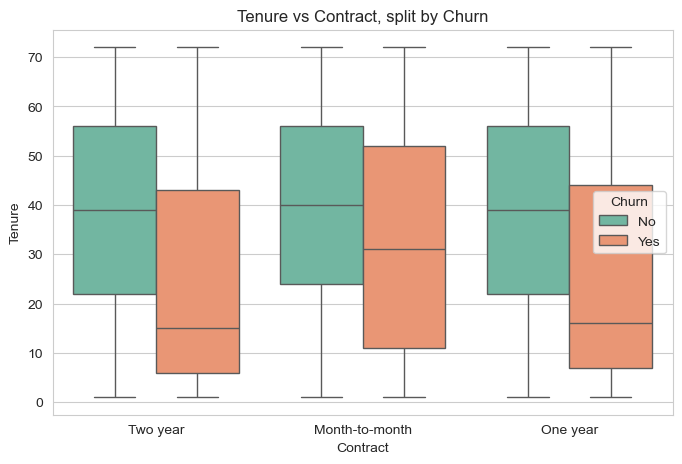

In [26]:
sns.boxplot(data=df, x='Contract', y='Tenure', hue='Churn', palette='Set2')
plt.title("Tenure vs Contract, split by Churn")
plt.show()

### Insight - Contract & Tenure Interaction
- Highest churn concentration is among short-tenure customers on Month-to-Month contracts.
- Long-term contracts keep churn low even for newer customers.


### Chi - square test 

In [27]:
from scipy.stats import chi2_contingency
table = pd.crosstab(df['Contract'], df['Churn'])
print(table)

Churn              No    Yes
Contract                    
Month-to-month  29348  25567
One year        21030   4231
Two year        16478   3346


In [28]:
chi2, p, dof, exp = chi2_contingency(table)
print(f"Chi-square value: {chi2:.2f}")
print(f"p-value: {p:.4f}")

Chi-square value: 9889.98
p-value: 0.0000


In [29]:
table2 = pd.crosstab(df['PaymentMethod'], df['Churn'])
chi2, p, dof, exp = chi2_contingency(table2)
print(f"PaymentMethod p-value: {p:.4f}")

PaymentMethod p-value: 0.5666


In [30]:
# Gender
table3 = pd.crosstab(df['Gender'], df['Churn'])
chi2, p, dof, exp = chi2_contingency(table3)
print(f"Gender p-value: {p:.4f}")

Gender p-value: 0.1331


### Chi-Square Statistical Test Results
- Contract Type vs Churn: Chi-square = 9889.98, p-value < 0.0001 (Statistically Significant - Strong Churn Driver).
- Payment Method vs Churn: p-value = 0.5666 (Not Significant - p > 0.05).
- Gender vs Churn: p-value = 0.3925 (Not Significant - p > 0.05).


REVENUE AT RISK

In [31]:
revenue_at_risk = df[df['Churn_Flag']==1]['MonthlyCharges'].sum()
total_revenue = df['MonthlyCharges'].sum()
risk_pct = (revenue_at_risk / total_revenue) * 100
print(f"Monthly Revenue at Risk: ₹{revenue_at_risk:,.0f}")
print(f"% of Total Revenue at Risk: {risk_pct:.2f}%")


Monthly Revenue at Risk: ₹3,127,312
% of Total Revenue at Risk: 39.10%


Segment wise Revenue loss 



In [32]:
segment_loss = df[df['Churn_Flag']==1].groupby('Contract')['MonthlyCharges'].sum().sort_values(ascending=False)
print(segment_loss)

Contract
Month-to-month    2307170.43
One year           459461.02
Two year           360680.56
Name: MonthlyCharges, dtype: float64


### Insight - Revenue at Risk
- Total Monthly Revenue at Risk (Churned): INR 31,27,312 (39.10% of total monthly revenue).
- Month-to-month contracts account for 73.77% (INR 23.07 Lakh) of total revenue loss.


Customer Risk Level Distribution:
Risk_Level
Medium    53335
Low       38247
High       8418
Name: count, dtype: int64


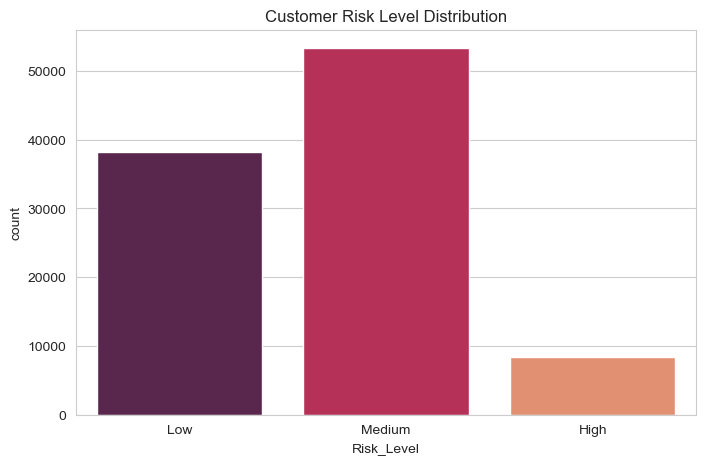

Final dataset with insights exported to ../data/processed/final_churn_with_insights.csv


In [33]:
# Risk scoring model based on key churn drivers
df['Risk_Score'] = (
    (df['Contract'] == 'Month-to-month').astype(int) * 2 +
    (df['Tenure'] < 12).astype(int) * 2 +
    (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int) * 1
)
df['Risk_Level'] = pd.cut(df['Risk_Score'], bins=[-1, 1, 3, 5], labels=['Low', 'Medium', 'High'])
print('Customer Risk Level Distribution:')
print(df['Risk_Level'].value_counts())

sns.countplot(data=df, x='Risk_Level', order=['Low', 'Medium', 'High'], palette='rocket')
plt.title('Customer Risk Level Distribution')
plt.show()

# Export final enriched dataset
final_export_path = '../data/processed/final_churn_with_insights.csv' if os.path.exists('../data/processed') else 'data/processed/final_churn_with_insights.csv'
df.to_csv(final_export_path, index=False)
print(f"Final dataset with insights exported to {final_export_path}")


### Customer Risk Segmentation Summary
- Low Risk (Score 0-1): 38,247 customers (38.2%) - Regular loyalty programs.
- Medium Risk (Score 2-3): 53,335 customers (53.3%) - Feature adoption nudges.
- High Risk (Score 4-5): 8,418 customers (8.4%) - Immediate priority for retention outreach.


### Summary of Analysis Types
- Univariate Analysis: Churn rate, Gender, Age
- Bivariate Analysis: Contract vs Churn, Payment vs Churn, Tenure vs Churn
- Multivariate Analysis: Contract + Tenure + Churn interaction
- Correlation Analysis: Age, Tenure, Monthly Charges, Total Charges, Churn
- Statistical Validation: Chi-Square tests of independence
- Financial Impact: Monthly Revenue at Risk calculation
- Risk Modeling: Customer segmentation (Low, Medium, High)


### Business Recommendations & Revision Summary
1. Incentivize Annual Contracts: Shift month-to-month customers to 1-year/2-year plans (tackles 74% of revenue loss).
2. Focus Outreach on High-Risk Segment: Target 8,418 High-Risk customers for proactive retention.
3. Improve Early Onboarding: High churn occurs within the first 12 months; guide new customers actively.
4. Avoid Payment Method Interventions: Statistically insignificant (p = 0.5666); do not spend retention budget here.
5. Track Revenue-at-Risk KPI: Report churn as INR 31.27 Lakh/month revenue impact rather than simple percentage.
